In [1]:
import OptimalBattery.simulate as sim
import OptimalBattery.util as ut
import OptimalBattery.plot as plot
import OptimalBattery.evaluate as ev
import HierarchBayesParcel.spatial as spatial
import HierarchBayesParcel.arrangements as ar
import torch as pt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd



# start with some U_true and make it arrange.logpi

In [2]:
height = 30
width = 30
K_main = 5
K_subparcels = 5
K_total = 25

grid = spatial.SpatialGrid(height, width)
arrangeT = ar.ArrangeIndependent(K=25, P=grid.P)
# centroids = [(0, 0), (29, 0), (0, 29), (29, 29), (14, 14)]
# define centroids more systematically
center_1 = (0, 0)
center_5 = (int((height-1)/2), int((width-1)/2))
center_2 = (width-1,0 )
center_4 = (height-1, width-1)
center_3 = (0, height-1)
centroids = [center_1, center_2, center_3, center_4, center_5]
print(centroids)


[(0, 0), (29, 0), (0, 29), (29, 29), (14, 14)]


In [3]:
custom_cmap = plot.create_custom_colormap(['red', 'blue', 'green', 'yellow', 'purple'],K_subparcels=5)

In [4]:
def plot_Us(U,title = None):
    if type(U) == np.ndarray:
        U = pt.tensor(U)
    parcel_labels_plot = U.argmax(dim=0).numpy()
    parcel_labels_plot = parcel_labels_plot.reshape((height, width))
    plt.imshow(parcel_labels_plot, cmap=custom_cmap)
    if title is not None:
        plt.title(title)
    else:
        plt.title('figure')
    return
    

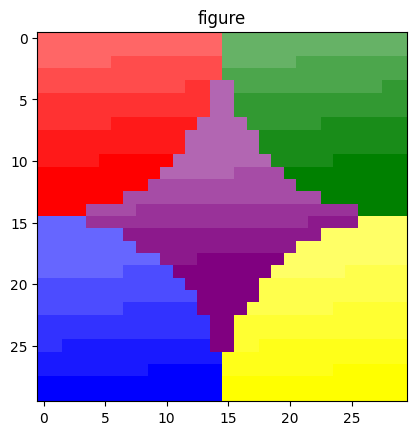

In [5]:
U_true_25 = sim.make_U_spatial(grid, centroids, K_main, K_subparcels)
U_true_25 = pt.tensor(U_true_25, dtype=pt.float32)
arrangeT.logpi = pt.log(U_true_25)

plot_Us(U_true_25)

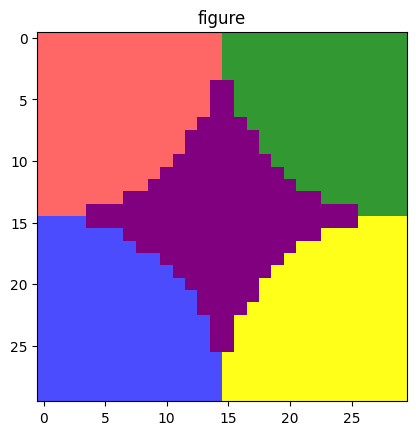

In [6]:
U_true_5 = sim.make_U_spatial(grid, centroids, K_main, 1)
plot_Us(U_true_5)
U_true_5 = U_true_5[np.newaxis, :, :]

# Make Vs based on a task covariance + parcel covariance

Covarince across parcels R

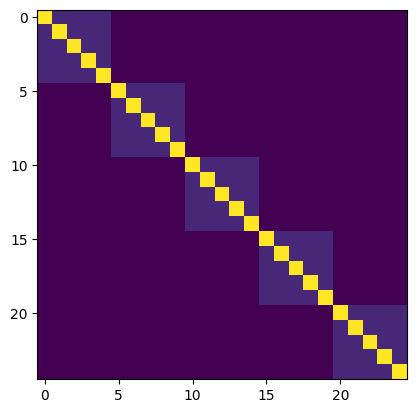

In [20]:
R= sim.custom_R(K_total =25, group_size=5, base_parcel_correlation=0.1, sub_parcel_extra_correlation=0.1)
plt.imshow(R)


covariance across tasks G

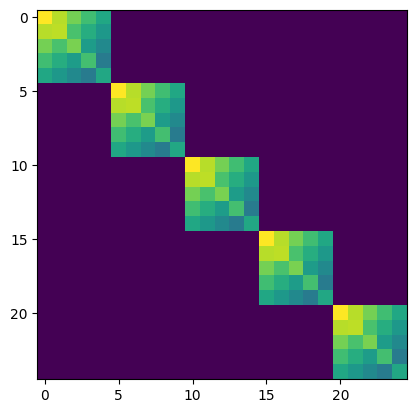

In [21]:
variance_factors = [[1,0.9,0.8,0.7,0.6],[1,0.9,0.8,0.7,0.6],[1,0.9,0.8,0.7,0.6],[1,0.9,0.8,0.7,0.6],[1,0.9,0.8,0.7,0.6]]
G = sim.custom_G(n_tasks=25, n_groups=5, group_size=5, target_corr=0.99, variance_factors=variance_factors)
plt.imshow(G)

make Vs (this num_iter gives a good V)

7.800315284163154
7.799811758125263
7.766943758230029
7.734753475167068
7.729324578114672
7.701420562706923
7.6953865721853525


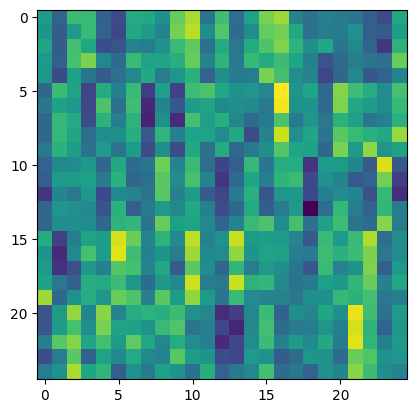

In [22]:
Vs_25= sim.find_best_V(G=G,R=R,num_iter=16000,rng = np.random.default_rng(101))
plt.imshow(Vs_25)


check covariance across rows and columns

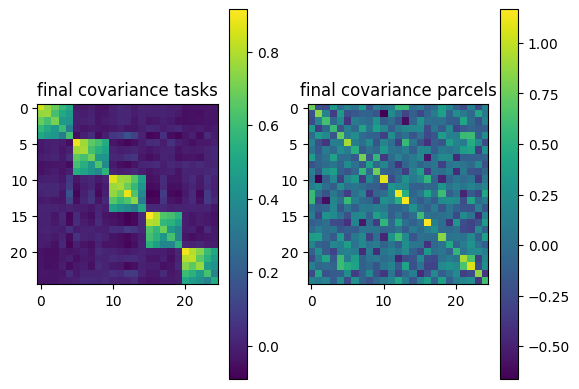

In [23]:
plt.subplot(1, 2, 1)
plt.imshow(Vs_25 @ Vs_25.T, cmap='viridis')
plt.colorbar()
plt.title('final covariance tasks')

plt.subplot(1, 2, 2)
plt.imshow(Vs_25.T @ Vs_25, cmap='viridis')
plt.colorbar()
plt.title('final covariance parcels')
plt.show()


lower dimensional Vs (just for the 5 main parcels)

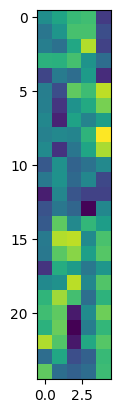

In [24]:
Vs_5 = Vs_25.reshape(25, 5, 5).mean(axis=2)
plt.imshow(Vs_5)

make true data

In [25]:
Y_true = Vs_25 @ np.array(U_true_25)


G matrix used for eigenmetrics

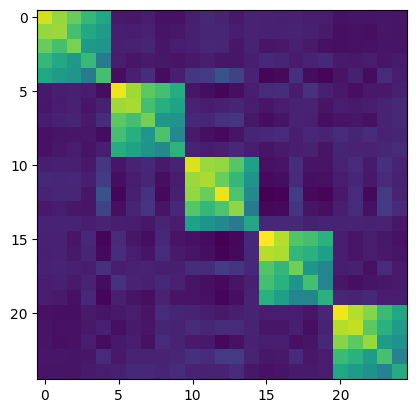

In [26]:
G_lib = Y_true @ Y_true.T
G_lib = np.array(G_lib)
plt.imshow(G_lib)

# Build combination dataframe

In [27]:
D = ut.build_combinations(G_lib, strategy='balanced',n_iter=1000,n_tasks=8,seed=605,balanced_sampling_unique=[2,3,4,5,6,7,8])
n_min = D['n_unique'].value_counts().min()
D['n_unique'].value_counts()

building0


n_unique
8    142
5    142
4    142
6    142
3    142
7    142
2    132
Name: count, dtype: int64

In [28]:
noise_list = [0.01,0.02,0.04,0.08,0.16,0.32,0.64,1.28,2.56,5.12,10.24]
vtest = Vs_5
for noise in noise_list:
    ytest = Y_true + np.random.normal(0, noise, Y_true.shape)
    D_ev = ev.evaluate_dataframe_simulation_multiregion(D,Y_true, Vs_5, U_true_5,sig_e=noise,vtest=vtest,ytest=ytest)
    print(f'noise: {noise}')
    result_df =  ut.run_regression_for_unique(df=D_ev, x_variables=['log_det'],y_variable='cos',n= n_min -1, random_state=0)
    print(result_df)
    result_df =  ut.run_regression_for_unique(df=D_ev, x_variables=['variance'],y_variable='cos',n= n_min -1, random_state=0)
    print(result_df)
    



Processing combination: 0
noise: 0.01
   n_unique  intercept  R_squared  log_det_coef
0         2   0.504461   0.118860     -0.051625
1         3   0.287934   0.263126     -0.080314
2         4   0.180211   0.245441     -0.072327
3         5   0.122686   0.159332     -0.054169
4         6   0.013524   0.353612     -0.080594
5         7  -0.041626   0.173841     -0.040743
6         8  -0.086499   0.316821     -0.051598
   n_unique  intercept  R_squared  variance_coef
0         2   0.504461   0.129088      -0.053800
1         3   0.287934   0.266138      -0.080773
2         4   0.180211   0.077753      -0.040709
3         5   0.122686   0.157604      -0.053875
4         6   0.013524   0.205612      -0.061456
5         7  -0.041626   0.177322      -0.041149
6         8  -0.086499   0.176613      -0.038524
Processing combination: 0
noise: 0.02
   n_unique  intercept  R_squared  log_det_coef
0         2   0.508008   0.123802     -0.051976
1         3   0.295224   0.288313     -0.081496
2   